In [3]:
import re

def count_words_excluding_brackets(text):
    # Remove all text inside (), [], or {}
    cleaned = re.sub(r"\(.*?\)|\[.*?\]|\{.*?\}", "", text)
    # Split on whitespace and count non-empty words
    words = cleaned.split()
    return len(words)

# Prompt user for input
user_input = input("Enter your text: ")
count = count_words_excluding_brackets(user_input)
print(f"Word count (excluding brackets): {count}")


Enter your text:  This report outlines steps taken to construct a harmonised dataset for Parkinson disease (PD) drug repositioning. Key stages (Figure 1) include disease-term mapping, bioactivity data curation, preparation for hierarchy-aware scoring and machine learning (ML). To construct a coordinated dataset of PD-associated genes suitable for compound-target analysis, we began with DisGeNET (v2024) under an academic license, querying the curated subset linked to the Concept Unique Identifier (CUI) for PD (C0030567). DisGeNET provides expert-curated gene-disease associations (GDAs) from trusted sources such as CLINGEN, PSYGENET, ORPHANET, and UNIPROT, with each association annotated by score and evidence class.1 To standardise disease identifiers across biomedical vocabularies, we employed a hybrid approach combining precomputed MedGen mappings and real-time queries to the Unified Medical Language System (UMLS) REST API. Each CUI was mapped to its corresponding MeSH Unique Identifie

Word count (excluding brackets): 2674


$$
\text{CSS}_{\text{Final}} =
\begin{cases}
\text{CSS}_{\text{Local}}, & \text{if } C \geq 50 \text{ or functional site is covered} \\\\
\text{CSS}_{\text{Local}} \times \left( \dfrac{C}{100} \right), & \text{if } C < 50 \text{ and functional site is not covered}
\end{cases}
$$

**CSS<sub>Local</sub>**: Normalised crystal structure score based on PD-specific scaling  
**C**: Percentage of UniProt sequence covered by high-resolution crystal structures (0–100)  
*Coverage is only penalised when functional sites are not within the crystallised region*


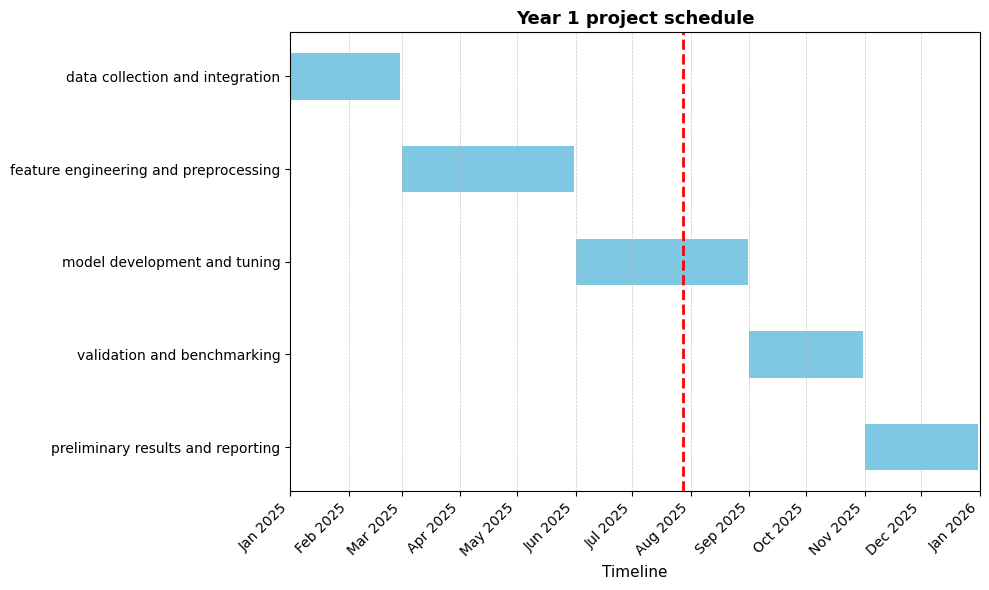

In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from datetime import datetime

# Define task schedule
tasks = [
    ("data collection and integration", "2025-01-01", "2025-02-28"),
    ("feature engineering and preprocessing", "2025-03-01", "2025-05-31"),
    ("model development and tuning", "2025-06-01", "2025-08-31"),
    ("validation and benchmarking", "2025-09-01", "2025-10-31"),
    ("preliminary results and reporting", "2025-11-01", "2025-12-31")
]

# Convert to DataFrame
df = pd.DataFrame(tasks, columns=["Task", "Start", "End"])
df["Start"] = pd.to_datetime(df["Start"])
df["End"] = pd.to_datetime(df["End"])
df["Duration"] = df["End"] - df["Start"]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Add task bars
for i, row in df.iterrows():
    ax.barh(
        y=i,
        width=row["Duration"].days,
        left=row["Start"],
        height=0.5,
        color="#7ec8e3"
    )

# Add "Now" arrow
now = pd.to_datetime("2025-07-28")
ax.axvline(now, color="red", linestyle="--", lw=2)
ax.annotate(
    "Now", xy=(now, len(df)), xytext=(now, len(df) + 0.3),
    ha='center', color='red', fontsize=11,
    arrowprops=dict(arrowstyle='->', color='red')
)

# X-axis formatting
ax.set_xlim(pd.to_datetime("2025-01-01"), pd.to_datetime("2026-01-01"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right')
ax.set_xlabel("Timeline", fontsize=11)

# Y-axis formatting
ax.set_yticks(range(len(df)))
ax.set_yticklabels(df["Task"], fontsize=10)
ax.invert_yaxis()

# Grid
ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.7)

# Title
ax.set_title("Year 1 project schedule", fontsize=13, weight="bold")

plt.tight_layout()
plt.show()
